# 12 — EKF SLAM with Range-Bearing Landmarks

**Section:** SLAM · **Mirrors MATLAB:** *2D Lidar SLAM Implementations* (full SLAM, not just localization)

EKF-SLAM jointly estimates the robot pose **and** the positions of $N$ landmarks. The state vector is:

$$\mu = [x_r,\ y_r,\ \theta_r,\ x_{\ell_1},\ y_{\ell_1},\ \dots,\ x_{\ell_N},\ y_{\ell_N}]^T$$

Each time we observe a landmark for the first time, we **initialize** its position from the current robot pose and observation.


## Intuition — what's actually going on?

SLAM (Simultaneous Localization and Mapping) is the holy grail of mobile robotics: a robot dropped into a brand-new place that has to **build a map and figure out where it is on that map at the same time**. It's a chicken-and-egg problem — without a map you can't localize, without localizing you can't build a map.

The EKF-SLAM solution is to put both into one big state vector: `[robot_x, robot_y, robot_θ, landmark_1_x, landmark_1_y, landmark_2_x, ...]`. The Kalman filter then jointly estimates every entry. The key insight is the **covariance matrix is full** — the robot's pose uncertainty is correlated with every landmark's position uncertainty. When you see a landmark and correct your estimate of *its* position, your *own* position estimate also gets sharper. That's the magic of SLAM.

EKF-SLAM's downside is the state vector grows with the number of landmarks, so the covariance update is O(N²) per step. Modern SLAM systems use sparser representations (factor graphs, e.g. GTSAM, g2o) for large maps — but EKF-SLAM is the cleanest place to learn the core ideas.


## Analytical derivation

**Augmented state.** Stack robot pose and $N$ landmark positions:

$$\mu = [x_r,\ y_r,\ \theta_r,\ x_{\ell_1},\ y_{\ell_1},\ \dots,\ x_{\ell_N},\ y_{\ell_N}]^T \in \mathbb{R}^{3+2N}$$

Covariance $\Sigma \in \mathbb{R}^{(3+2N)\times(3+2N)}$ is full — the joint posterior couples the robot to every landmark seen.

**Prediction step.** The control $u = (v, \omega)$ moves only the robot:

$$\mu_{t+1}^{1:3} = \mu_t^{1:3} + \Delta t \begin{bmatrix} v\cos\theta_r \\ v\sin\theta_r \\ \omega \end{bmatrix},\qquad \mu_{t+1}^{4:} = \mu_t^{4:}$$

The full-state Jacobian $G$ is identity except for the $3\times 3$ block in the top-left:

$$G = I_{3+2N} + \begin{bmatrix} G_r - I_3 & 0 \\ 0 & 0 \end{bmatrix},\qquad G_r = \begin{bmatrix} 1 & 0 & -v\sin\theta_r\,\Delta t \\ 0 & 1 & v\cos\theta_r\,\Delta t \\ 0 & 0 & 1 \end{bmatrix}$$

Predict covariance: $\Sigma = G \Sigma G^T + F^T Q F$ where $F = [I_3,\ 0]$ injects process noise into only the robot block.

**Landmark initialization.** When landmark $j$ is first observed with $(r, \phi)$:

$$\mu^{\ell_j} = \mu^r + r \begin{bmatrix} \cos(\theta_r + \phi) \\ \sin(\theta_r + \phi) \end{bmatrix}$$

**Observation update.** For range-bearing observation $z = (r, \phi)$ of landmark $j$ at $(\ell_x, \ell_y)$, define $\delta = (\delta_x, \delta_y) = (\ell_x - x_r, \ell_y - y_r)$ and $q = \delta^T\delta$. The expected measurement is

$$\hat z = \begin{bmatrix} \sqrt{q} \\ \arctan2(\delta_y, \delta_x) - \theta_r \end{bmatrix}$$

**Sparse observation Jacobian.** Only the robot-pose columns (1–3) and the columns of landmark $j$ (3+2j-1, 3+2j) are nonzero:

$$H \in \mathbb{R}^{2 \times (3+2N)}:\quad H_{(1:2,\,r)} = \frac{1}{q}\begin{bmatrix} -\sqrt{q}\delta_x & -\sqrt{q}\delta_y & 0 \\ \delta_y & -\delta_x & -q \end{bmatrix},\quad H_{(1:2,\,\ell_j)} = \frac{1}{q}\begin{bmatrix} \sqrt{q}\delta_x & \sqrt{q}\delta_y \\ -\delta_y & \delta_x \end{bmatrix}$$

Innovation: $\nu = z - \hat z$ (wrap bearing to $(-\pi, \pi]$). Innovation covariance: $S = H \Sigma H^T + R$. Kalman gain: $K = \Sigma H^T S^{-1}$. Update:

$$\mu \leftarrow \mu + K\nu,\qquad \Sigma \leftarrow (I - K H)\,\Sigma$$

The cross-correlations in $\Sigma$ are what couple robot-pose corrections to landmark refinements — that's where the "SLAM" magic lives.

### Compatibility check — math ↔ code

| Step | Code |
|---|---|
| Robot motion in augmented state | `mu[:3] = mu[:3] + dt * np.array([u[0]*np.cos(th), u[0]*np.sin(th), u[1]])` |
| Sparse motion Jacobian (identity + robot block) | `G = np.eye(n); G[0,2] = -dt*u[0]*np.sin(th); G[1,2] = dt*u[0]*np.cos(th)` |
| Inject process noise via $F$ | `F = np.zeros((3, n)); F[:3,:3] = np.eye(3); Sigma = G @ Sigma @ G.T + F.T @ Q @ F` |
| First-observation landmark init | `mu[3+2*i] = mu[0] + z[0]*np.cos(z[1]+mu[2]); mu[3+2*i+1] = ...sin(...)` |
| Expected measurement $\hat z$ | `z_hat = np.array([r, wrap(np.arctan2(dy, dx) - mu[2])])` |
| Sparse $H$ (only robot cols + landmark $j$ cols filled) | `H = np.zeros((2, n)); H[:, :3] = ...; H[:, 3+2*i:3+2*i+2] = ...` |
| Kalman update | `K = Sigma @ H.T @ np.linalg.inv(S); mu = mu + K @ innov; Sigma = (I - K @ H) @ Sigma` |


In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(1)

T = 200; dt = 0.1
v, omega = 1.0, 0.1
true_robot = np.zeros((T, 3))
for k in range(1, T):
    th = true_robot[k - 1, 2]
    true_robot[k] = true_robot[k - 1] + dt * np.array([v * np.cos(th), v * np.sin(th), omega])

true_lm = np.array([[5, 5], [-5, 5], [0, -8], [7, -2]])
N_LM = len(true_lm)
n = 3 + 2 * N_LM


In [2]:
mu = np.zeros(n)
Sigma = np.eye(n) * 1e6
Sigma[:3, :3] = np.eye(3) * 0.01

Q = np.diag([0.05, 0.05, 0.01]) ** 2
R_obs = np.diag([0.2, 0.05]) ** 2
seen = [False] * N_LM
mu_hist = [mu.copy()]


def wrap(a):
    return (a + np.pi) % (2 * np.pi) - np.pi


for k in range(1, T):
    u = [v + np.random.randn() * 0.05, omega + np.random.randn() * 0.01]
    th = mu[2]
    mu[:3] = mu[:3] + dt * np.array([u[0] * np.cos(th), u[0] * np.sin(th), u[1]])
    G = np.eye(n)
    G[0, 2] = -dt * u[0] * np.sin(th)
    G[1, 2] =  dt * u[0] * np.cos(th)
    F = np.zeros((3, n)); F[:3, :3] = np.eye(3)
    Sigma = G @ Sigma @ G.T + F.T @ Q @ F

    for i, lm in enumerate(true_lm):
        z = np.array([
            np.linalg.norm(lm - true_robot[k, :2]),
            np.arctan2(lm[1] - true_robot[k, 1], lm[0] - true_robot[k, 0]) - true_robot[k, 2],
        ]) + np.random.multivariate_normal([0, 0], R_obs)

        if not seen[i]:
            mu[3 + 2 * i]     = mu[0] + z[0] * np.cos(z[1] + mu[2])
            mu[3 + 2 * i + 1] = mu[1] + z[0] * np.sin(z[1] + mu[2])
            seen[i] = True

        dx = mu[3 + 2 * i] - mu[0]
        dy = mu[3 + 2 * i + 1] - mu[1]
        q = dx * dx + dy * dy
        r = np.sqrt(q)
        z_hat = np.array([r, wrap(np.arctan2(dy, dx) - mu[2])])
        innov = z - z_hat
        innov[1] = wrap(innov[1])

        H = np.zeros((2, n))
        H[0, 0] = -dx / r;  H[0, 1] = -dy / r
        H[1, 0] =  dy / q;  H[1, 1] = -dx / q;  H[1, 2] = -1
        H[0, 3 + 2 * i] =  dx / r;  H[0, 3 + 2 * i + 1] =  dy / r
        H[1, 3 + 2 * i] = -dy / q;  H[1, 3 + 2 * i + 1] =  dx / q

        S = H @ Sigma @ H.T + R_obs
        K = Sigma @ H.T @ np.linalg.inv(S)
        mu = mu + K @ innov
        Sigma = (np.eye(n) - K @ H) @ Sigma

    mu_hist.append(mu.copy())

mu_hist = np.array(mu_hist)
for i in range(N_LM):
    err = np.linalg.norm(mu[3 + 2 * i: 3 + 2 * i + 2] - true_lm[i])
    print(f"LM {i}: true={true_lm[i]}  est=({mu[3+2*i]:+.2f}, {mu[3+2*i+1]:+.2f})  err={err:.3f} m")


LM 0: true=[5 5]  est=(+5.19, +4.86)  err=0.238 m
LM 1: true=[-5  5]  est=(-4.78, +5.25)  err=0.331 m
LM 2: true=[ 0 -8]  est=(-0.21, -8.00)  err=0.211 m
LM 3: true=[ 7 -2]  est=(+6.94, -2.23)  err=0.233 m


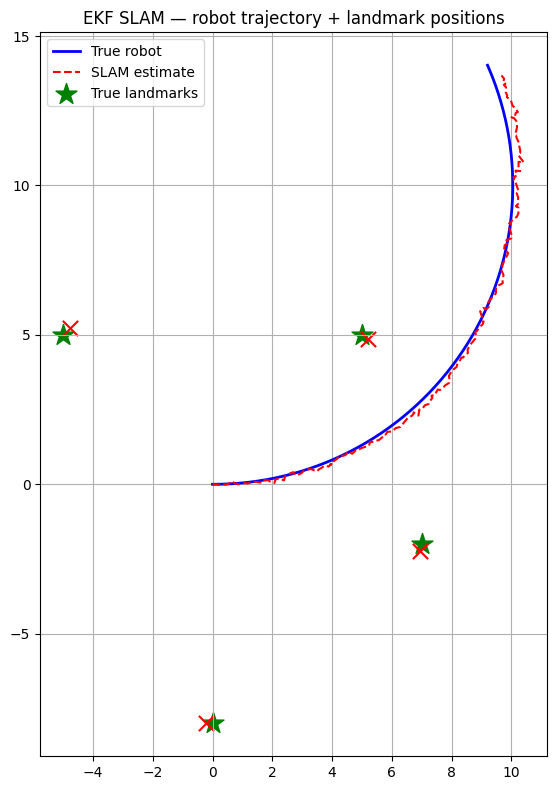

In [3]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(true_robot[:, 0], true_robot[:, 1], 'b-', lw=2, label='True robot')
ax.plot(mu_hist[:, 0], mu_hist[:, 1], 'r--', lw=1.5, label='SLAM estimate')
ax.scatter(true_lm[:, 0], true_lm[:, 1], c='g', marker='*', s=250, label='True landmarks')
for i in range(N_LM):
    ax.scatter(mu[3 + 2 * i], mu[3 + 2 * i + 1], c='r', marker='x', s=120)
ax.set_aspect('equal'); ax.grid(); ax.legend()
ax.set_title('EKF SLAM — robot trajectory + landmark positions')
plt.tight_layout()
plt.show()


## References & rigor notes

**Consistency caveat.** Vanilla EKF-SLAM is known to be **inconsistent** — the estimated covariance becomes overconfident over long trajectories (Bailey et al., 2006). Mitigations: First-Estimates Jacobian EKF (FEJ-EKF), Observability-Constrained EKF (OC-EKF), or switch to graph-based SLAM (factor graphs, GTSAM).

**Complexity.** Per step: prediction is $O(N)$ where $N$ = number of landmarks; each landmark observation update is $O(N^2)$ due to the dense covariance update. Total $O(M \cdot N^2)$ per step for $M$ observations. For maps with hundreds of landmarks this dominates; factor-graph SLAM (e.g., GTSAM, g2o) exploits sparsity to scale near-linearly.

**Joint estimation magic.** The covariance off-diagonal blocks couple robot pose to landmarks. Each time a landmark is observed, both its estimate *and* the robot pose estimate sharpen — this cross-correlation is the entire reason SLAM works at all.

**References.**
- Smith, R., Self, M., & Cheeseman, P. (1990). *Estimating uncertain spatial relationships in robotics*. Autonomous Robot Vehicles, Springer, 167-193.
- Dissanayake, M. W. M. G., Newman, P., Clark, S., Durrant-Whyte, H., & Csorba, M. (2001). *A solution to the simultaneous localization and map building (SLAM) problem*. IEEE Trans. Robotics & Automation, 17(3).
- Bailey, T., Nieto, J., Guivant, J., Stevens, M., & Nebot, E. (2006). *Consistency of the EKF-SLAM algorithm*. IROS 2006.
- Cadena, C. et al. (2016). *Past, present, and future of simultaneous localization and mapping: Toward the robust-perception age*. IEEE Trans. Robotics, 32(6).
